In [1]:
import torch
from torch.utils.data import Dataset
import pickle
import random

AA_TO_INDEX = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4,
    'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
    'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19,
    '-': 20, 'X': 20  
}

class MSADataset(Dataset):
    def __init__(self, df, msa_dict_path, max_depth=80, win_size=61, aug=False):
        with open(msa_dict_path, "rb") as f:
            self.msa_dict = pickle.load(f)
        self.df = df
        self.max_depth = max_depth
        self.win_size = win_size
        self.half_win = win_size // 2  # 중심에서 양쪽 길이
        self.aug = aug
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = int(row["MutPos"]) - 1  # 1-based → 0-based
        label = float(row["Label"]) 

        mut = row["Mut"].upper()

        msa_seqs = [seq for _, seq in self.msa_dict[uid][:self.max_depth]]
        query_seq = msa_seqs[0]  # 보통 첫 줄이 ref seq

        # 변이 반영된 mut_seq 생성
        mut_seq = list(query_seq)
        if 0 <= mut_pos < len(mut_seq):
            mut_seq[mut_pos] = mut

        # 사용될 시퀀스: 변이 시퀀스 + ref 시퀀스 + MSA
        seqs_to_use = [mut_seq, list(query_seq)]
        if len(msa_seqs) > 1:
            seqs_to_use += [list(seq) for seq in msa_seqs[1:self.max_depth - 2]]

        if self.aug:
            msa_part = seqs_to_use[2:]  # 변이+ref 제외
            random.shuffle(msa_part)   # 순서 섞기
            seqs_to_use = seqs_to_use[:2] + msa_part

        centered_msa = []
        for seq in seqs_to_use:
            window = []
            for i in range(self.win_size):
                seq_idx = mut_pos - self.half_win + i
                if 0 <= seq_idx < len(seq):
                    aa = seq[seq_idx]
                else:
                    aa = '-'
                window.append(AA_TO_INDEX.get(aa, 20))
            centered_msa.append(window)

        # depth padding
        while len(centered_msa) < self.max_depth:
            centered_msa.append([20] * self.win_size)  # 20은 패딩 인덱스

        msa_tensor = torch.tensor(centered_msa[:self.max_depth]).long()  # [D, L]
        msa_tensor = msa_tensor.transpose(0, 1)  # [L, D]

        return {
            "msa": msa_tensor,  # [L, D]
            "label": torch.tensor(label).float()
        }


In [2]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba
from mamba_ssm import Mamba2


# --- Input Embedding ---
class MSAInputEmbedding(nn.Module):
    def __init__(self, vocab_size=21, dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=dim)

    def forward(self, x):  # x: (B, L, D)
        return self.embedding(x)  # → (B, L, D, C)

# --- MambaRMSNorm ---
class MambaRMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        norm = x.norm(dim=-1, keepdim=True) / (x.shape[-1] ** 0.5)
        return self.weight * x / (norm + self.eps)

# --- Cross-Axial Mamba Block ---
class CrossAxialMambaMSA(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm_L = MambaRMSNorm(dim)
        self.norm_D = MambaRMSNorm(dim)

        self.mamba_L = Mamba(d_model=dim, expand=1)
        self.conv_D = nn.Conv1d(in_channels=dim, out_channels=dim, kernel_size=5, padding=2)

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2  # = 30

        # --- D-axis: only at center L position ---
        x_d_center = self.norm_D(x[:, center_L])  # (B, D, C)
        x_d = x_d_center.transpose(1, 2)          # (B, C, D)
        d_out = self.conv_D(x_d).transpose(1, 2).unsqueeze(1)  # (B, 1, D, C)

        # --- L-axis: full Mamba ---
        x_l = self.norm_L(x).permute(0, 2, 1, 3).contiguous().view(B * D, L, C)
        l_out = self.mamba_L(x_l).view(B, D, L, C).permute(0, 2, 1, 3)  # (B, L, D, C)

        # --- Residual ---
        # d_out is only for center, rest is zero
        d_full = torch.zeros_like(x)
        d_full[:, center_L:center_L+1] = d_out

        return x + d_full + l_out


# # --- Encoder ---
class MSAEncoder(nn.Module):
    def __init__(self, num_layers=8, dim=256):
        super().__init__()
        self.embeddings = MSAInputEmbedding(dim=dim)
        self.blocks = nn.ModuleList([
            CrossAxialMambaMSA(dim) for _ in range(num_layers)
        ])
        self.norm_f = MambaRMSNorm(dim)

    def forward(self, x):  # x: (B, L, D)
        x = self.embeddings(x)  # → (B, L, D, C)
        for block in self.blocks:
            x = block(x)
        return self.norm_f(x)  # (B, L, D, C)

# --- Classifier Head ---
class MSAClassifier(nn.Module):
    def __init__(self, num_layers=4, dim=128, num_classes=2):
        super().__init__()
        self.encoder = MSAEncoder(num_layers=num_layers, dim=dim)

        self.classifier = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):  # x: (B, L, D)
        x = self.encoder(x)                  # (B, L, D, C)
        center_L = x.shape[1] // 2           # 30
        x = x[:, center_L]                   # (B, D, C)
        x = x.mean(dim=1)                    # mean over D → (B, C)
        out = self.classifier(x)             # (B, num_classes)
        return out


/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.model_selection import KFold

df = pd.read_csv("/mnt/c/Users/Kunny/Research/Project/BiConVarNet/ARSA/sample_data.tsv", sep="\t")

test_dataset   = MSADataset(df, "/mnt/e/CAGI_data/msa_dict_valid.pkl", aug=False)

# 5. Dataloader
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

In [4]:
print(df["Label"].describe())

count    349.000000
mean       0.599977
std        0.161886
min        0.130000
25%        0.497000
50%        0.618000
75%        0.730000
max        0.935000
Name: Label, dtype: float64


In [13]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, roc_auc_score
from scipy.stats import pearsonr, kendalltau
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MSAClassifier(num_layers=8, dim=128, num_classes=1).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250804.pth"))
model.eval()

def temperature_scaled_sigmoid(logits, T=2.0):
    return torch.sigmoid(logits / T)

criterion = nn.BCEWithLogitsLoss()  # 또는 MSELoss
val_loss = 0
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        x = batch["msa"].to(device)
        y = batch["label"].float().to(device)

        logits = model(x).squeeze(-1)
        loss = criterion(logits, y)

        probs = temperature_scaled_sigmoid(logits, T=4) 
        probs = 1 - probs              # 병원성 → 안정성 변환

        val_loss += loss.item() * x.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Convert to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# === Evaluation Metrics ===
avg_val_loss = val_loss / len(test_loader.dataset)
mse = mean_squared_error(all_labels, all_probs)
pearson_r, _ = pearsonr(all_labels, all_probs)
kendall_tau, _ = kendalltau(all_labels, all_probs)

# AUC (if you assume 0.5 as threshold for binary label)
try:
    binary_labels = (all_labels >= 0.5).astype(int)
    auc = roc_auc_score(binary_labels, all_probs)
except:
    auc = float('nan')


# === Print Results ===
print(f"Avg BCE Loss:     {avg_val_loss:.4f}")
print(f"MSE:              {mse:.4f}")
print(f"Pearson r:        {pearson_r:.4f}")
print(f"Kendall's Tau:    {kendall_tau:.4f}")
print(f"AUC (bin@0.5):    {auc:.4f}")

Evaluating: 100%|██████████| 349/349 [00:05<00:00, 64.26it/s]

Avg BCE Loss:     2.1135
MSE:              0.0421
Pearson r:        0.4182
Kendall's Tau:    0.2686
AUC (bin@0.5):    0.6930


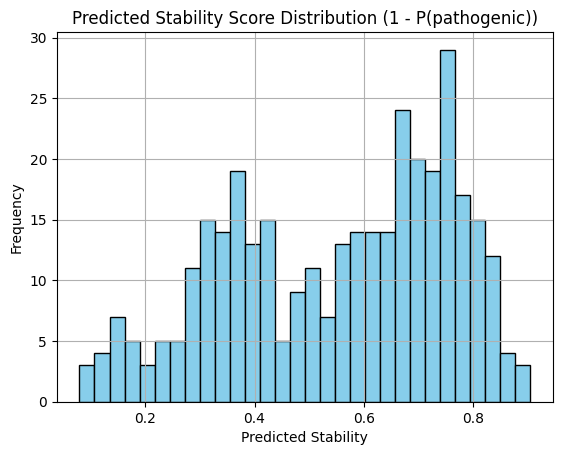

In [14]:
import matplotlib.pyplot as plt

plt.hist(all_probs, bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Stability Score Distribution (1 - P(pathogenic))")
plt.xlabel("Predicted Stability")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.hist(all_probs, bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Stability Score Distribution (1 - P(pathogenic))")
plt.xlabel("Predicted Stability")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()